# Klasifikasi Spasial Lahan Sawah dan Non-Sawah

Bagian ini mendokumentasikan tahapan akuisisi citra satelit optik **Sentinel-2A (Level-2A)** dalam format GeoTIFF (`.tif`) melalui **openEO**, ekstraksi nilai spektral pada **100 titik sampel** (50 sampel Sawah dan 50 sampel Non-Sawah) yang telah dilabeli melalui **QGIS**, hingga pemodelan klasifikasi biner (2 kelas).

## Instalasi Library Yang Digunakan

```bash
pip install geopandas
```

```bash
pip install openeo
```

```bash
pip install scikit-learn
```

## 1. Desain Pengambilan Sampel (Ground Truth)

Pengambilan sampel dilakukan secara spasial dengan membagi objek pengamatan ke dalam dua kelas seimbang (*balanced dataset*) dalam format vektor (`Shapefile` / `GeoJSON`).

**Catatan Mengenai Format Geometri (Point vs Poligon):**
Data vektor yang digunakan (`sawah.zip` dan `non-sawah.zip`) pada dasarnya bisa berupa poligon (Polygon) maupun titik (Point) yang didigitasi melalui QGIS. Akan tetapi, di dalam proses ekstraksinya nanti, *script* Python secara otomatis menghitung **titik tengah (centroid)** dari geometri tersebut (`geom.centroid`). Ini berarti, meskipun Anda menggambar sebuah poligon yang luas, *script* ini hanya akan mengambil **satu nilai piksel** yang berada tepat di titik tengah poligon tersebut untuk mewakili keseluruhan sampel.

| Kelas Target | Kode Label | Jumlah Sampel | Karakteristik Objek |
| :--- | :---: | :---: | :--- |
| **Sawah** | `1` | 50 Sampel | Petak lahan pertanian padi aktif (fase vegetatif, genangan air/tanam, maupun pematangan) |
| **Non-Sawah** | `0` | 50 Sampel | Permukiman/bangunan, jalan raya, badan air permanen, dan vegetasi non-pertanian |
| **Total** | — | **100 Sampel** | Digabungkan menjadi satu *GeoDataFrame* berproyeksi `EPSG:4326` |

```python
import geopandas as gpd
import openeo
import pandas as pd

# ==============================================================================
# 1. BACA KEDUA FILE ZIP (SAWAH & NON-SAWAH) DAN BERI LABEL OTOMATIS
# ==============================================================================
# Sesuaikan nama file zip non-sawah milikmu di baris kedua
gdf_sawah = gpd.read_file("sawah.zip").to_crs("EPSG:4326")
gdf_nonsawah = gpd.read_file("non-sawah.zip").to_crs("EPSG:4326")

# Beri kolom label secara otomatis
gdf_sawah["label_teks"] = "Sawah"
gdf_sawah["label"] = 1

gdf_nonsawah["label_teks"] = "Non-Sawah"
gdf_nonsawah["label"] = 0

# Gabungkan keduanya menjadi 1 GeoDataFrame (50 + 50 = 100 sampel)
gdf_gabungan = gpd.GeoDataFrame(
    pd.concat([gdf_sawah, gdf_nonsawah], ignore_index=True), crs="EPSG:4326"
)

print(f"Jumlah sampel Sawah     : {len(gdf_sawah)}")
print(f"Jumlah sampel Non-Sawah : {len(gdf_nonsawah)}")
print(f"Total sampel gabungan   : {len(gdf_gabungan)}")

# ==============================================================================
# 2. AMBIL BATAS KOORDINAT GABUNGAN (BOUNDING BOX) UNTUK OPENEO
# ==============================================================================
minx, miny, maxx, maxy = gdf_gabungan.total_bounds
buffer_deg = 0.005  # Tambahan margin ~500 meter agar titik di tepi tetap masuk

bbox = {
    "west": float(minx - buffer_deg),
    "south": float(miny - buffer_deg),
    "east": float(maxx + buffer_deg),
    "north": float(maxy + buffer_deg),
}
print("Bounding Box Gabungan:", bbox)

# ==============================================================================
# 3. KONEKSI KE OPENEO & UNDUH SENTINEL-2A FORMAT GEOTIFF (.tif)
# ==============================================================================
conn = openeo.connect("openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()

datacube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=["2026-05-01", "2026-09-30"],  # Rentang waktu minim awan
    bands=[
        "B02",
        "B03",
        "B04",
        "B08",
        "B11",
    ],  # Blue, Green, Red, NIR, SWIR
    max_cloud_cover=10,
)

# Ambil median waktu agar bebas tutupan awan
composite_s2 = datacube.median_time()

# Unduh menjadi file GeoTIFF (.tif)
nama_tif = "sentinel2_sawah_nonsawah.tif"
print("Mengunduh citra Sentinel-2A (.tif)...")
composite_s2.download(nama_tif, format="GTiff")
print(f"Berhasil diunduh: {nama_tif}")
```

**Output:**

```
Jumlah sampel Sawah     : 50
Jumlah sampel Non-Sawah : 50
Total sampel gabungan   : 100
Bounding Box Gabungan: {'west': 112.8379972, 'south': -7.17026, 'east': 112.88253089999999, 'north': -7.1414391}
Authenticated using refresh token.
Mengunduh citra Sentinel-2A (.tif)...
Berhasil diunduh: sentinel2_sawah_nonsawah.tif
```

## 2. Akuisisi Citra Sentinel-2A (`.tif`) via openEO dan Ekstraksi Fitur

Akuisisi citra dilakukan menggunakan *bounding box* gabungan dari ke-100 titik sampel pada koleksi **`SENTINEL2_L2A`** (*Bottom-of-Atmosphere Reflectance*) dengan batas tutupan awan maksimum `< 10%` dan agregasi temporal `median_time()` untuk menghasilkan komposit citra bebas awan berformat **GeoTIFF (`.tif`)**.

### Fitur Spektral dan Indeks Turunan yang Diekstrak:

Sentinel-2 Level-2A menyediakan data citra dengan nilai pantulan permukaan (*Bottom-of-Atmosphere Reflectance*). Pada tahap ini, kita mengekstrak 5 band spektral utama dan menghitung 2 indeks turunan yang sangat relevan untuk membedakan karakteristik sawah (padi) dan non-sawah:

1. **Band Spektral Utama:**
   * **`B02` (Blue / Biru - 490 nm)**: Resolusi spasial 10m. Berguna untuk membedakan tanah dan vegetasi, serta identifikasi badan air dangkal (pantulan air lebih tinggi di spektrum biru).
   * **`B03` (Green / Hijau - 560 nm)**: Resolusi spasial 10m. Sangat sensitif terhadap pantulan klorofil, sehingga berguna untuk mengidentifikasi tingkat kehijauan vegetasi pada fase pertumbuhan padi.
   * **`B04` (Red / Merah - 665 nm)**: Resolusi spasial 10m. Klorofil menyerap cahaya merah secara kuat, menjadikannya band kunci yang selalu dipasangkan dengan band NIR untuk ekstraksi batas vegetasi (NDVI).
   * **`B08` (Near Infrared / NIR - 842 nm)**: Resolusi spasial 10m. Band paling penting untuk pengamatan vegetasi karena sel jaringan daun sehat memantulkan spektrum NIR sangat tinggi. Sawah dengan padi aktif akan terlihat terang (nilai pantulan tinggi) di band ini.
   * **`B11` (Short-Wave Infrared / SWIR - 1610 nm)**: Resolusi spasial 20m. Spektrum ini sangat sensitif terhadap kandungan air, baik di dalam tanaman maupun di tanah. Dalam konteks klasifikasi sawah, band ini krusial untuk mendeteksi fase persiapan lahan atau genangan air (karena genangan air menyerap gelombang SWIR dengan kuat).
2. **Normalized Difference Vegetation Index (NDVI):**

   $$\text{NDVI} = \frac{B08 - B04}{B08 + B04}$$

3. **Normalized Difference Water Index (NDWI):**

   $$\text{NDWI} = \frac{B03 - B08}{B03 + B08}$$

```python
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Buka file .tif Sentinel-2A dan samakan proyeksi koordinat (CRS)
with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  gdf_projected = gdf_gabungan.to_crs(src.crs)

  # Ambil titik tengah (centroid) dari tiap sampel (mendukung Point maupun Polygon)
  koordinat_sampel = [
      (geom.centroid.x, geom.centroid.y) for geom in gdf_projected.geometry
  ]

  # Ekstrak nilai piksel dari kelima band Sentinel-2A
  nilai_band = list(src.sample(koordinat_sampel))

# 2. Buat tabel DataFrame Fitur
df_dataset = pd.DataFrame(nilai_band, columns=["B02", "B03", "B04", "B08", "B11"])

# 3. Tambahkan fitur indeks vegetasi (NDVI) & indeks air (NDWI)
df_dataset["NDVI"] = (df_dataset["B08"] - df_dataset["B04"]) / (
    df_dataset["B08"] + df_dataset["B04"] + 1e-6
)
df_dataset["NDWI"] = (df_dataset["B03"] - df_dataset["B08"]) / (
    df_dataset["B03"] + df_dataset["B08"] + 1e-6
)

# 4. Masukkan Koordinat & Label Kelas (Sawah = 1, Non-Sawah = 0)
df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y
df_dataset["Kelas"] = gdf_gabungan["label_teks"]
df_dataset["Target"] = gdf_gabungan["label"]

# Simpan ke CSV (bisa dipakai juga kalau mau diolah di KNIME)
df_dataset.to_csv("dataset_100sampel_sawah_nonsawah.csv", index=False)
print("Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'")
display(df_dataset.head())
```

**Output:**

In [1]:
import pandas as pd
df_ekstraksi_cek_poly = pd.read_csv("./source/klasifikasi_sawah/dataset_100sampel_sawah_nonsawah.csv")
df_ekstraksi_cek_poly

,B02,B03,B04,B08,B11,NDVI,NDWI,Longitude,Latitude,Kelas,Target
0,440,650,792,3054,1696,0.588144,-0.649028,705909.311702,9.208287e+06,Sawah,1
1,530,665,760,2542,1651,0.539673,-0.585282,705962.229809,9.208277e+06,Sawah,1
2,607,832,990,2820,2803,0.480315,-0.544359,705840.417492,9.208291e+06,Sawah,1
3,475,610,637,2916,1800,0.641430,-0.653999,705858.986318,9.208239e+06,Sawah,1
4,623,802,886,2782,1808,0.516903,-0.552455,705966.022408,9.208230e+06,Sawah,1
...,...,...,...,...,...,...,...,...,...,...,...
94,676,971,1352,2498,2963,0.297662,-0.440184,706299.191362,9.209598e+06,Non-Sawah,0
95,387,615,992,2084,2762,0.355007,-0.544276,706293.717784,9.209561e+06,Non-Sawah,0
96,690,964,1259,2443,3013,0.319827,-0.434106,706564.976001,9.209393e+06,Non-Sawah,0
97,627,811,1192,2182,2991,0.293420,-0.458069,706699.568850,9.209600e+06,Non-Sawah,0


In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

df_ekstraksi_cek_poly = pd.read_csv("./source/klasifikasi_sawah/dataset_100sampel_sawah_nonsawah.csv")

fitur_kolom = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"]
X = df_ekstraksi_cek_poly[fitur_kolom]
y = df_ekstraksi_cek_poly["Kelas"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.value_counts())
print()
print(y_train.value_counts())
print(f"\n\n")

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

B02   B03   B04   B08   B11   NDVI      NDWI     
280   524   457   3263  2443  0.754301  -0.723264    1
340   747   493   3280  2194  0.738669  -0.629004    1
382   693   578   2927  2175  0.670185  -0.617127    1
384   615   667   2547  1721  0.584941  -0.611006    1
387   615   992   2084  2762  0.355007  -0.544276    1
                                                    ..
2132  2251  2390  2511  2086  0.024689  -0.054599    1
2470  2769  3118  3475  3685  0.054148  -0.113069    1
3114  3138  3142  3182  3773  0.006325  -0.006962    1
3793  4165  4436  4601  4931  0.018258  -0.049738    1
5461  5918  5903  6216  4305  0.025827  -0.024559    1
Name: count, Length: 79, dtype: int64

Kelas
Non-Sawah    40
Sawah        39
Name: count, dtype: int64





## 3. Hasil Evaluasi Klasifikasi 2 Kelas (Random Forest)

Dataset 100 sampel dibagi menggunakan skema *Stratified Train-Test Split* dengan proporsi **80% Data Latih (80 sampel: 40 Sawah, 40 Non-Sawah)** dan **20% Data Uji (20 sampel: 10 Sawah, 10 Non-Sawah)**.

**Cara Kerja Random Forest pada Klasifikasi Ini:**
Algoritma *Random Forest Classifier* dipilih karena kemampuannya yang tangguh (*robust*) dalam menangani data penginderaan jauh yang seringkali memiliki fitur spektral yang berkorelasi (seperti antar band berdekatan). Model ini bekerja melalui pendekatan *ensemble learning*, yaitu:
1. **Pembuatan Banyak Pohon (Forest):** Model membangun banyak *Decision Tree* atau Pohon Keputusan (pada *script* menggunakan `n_estimators=100`, artinya 100 pohon).
2. **Pengambilan Sampel Acak (Bagging):** Setiap pohon dilatih menggunakan kumpulan sampel acak dari data latih, dan pada tiap percabangannya, algoritma hanya mempertimbangkan subset fitur secara acak. Hal ini mencegah model dari *overfitting* (terlalu menghafal data latih).
3. **Voting Mayoritas:** Ketika melakukan prediksi piksel baru, ke-100 pohon ini akan memberikan hasil klasifikasi masing-masing. Kelas dengan "suara" (voting) terbanyak akan dipilih sebagai hasil akhir (Sawah atau Non-Sawah).

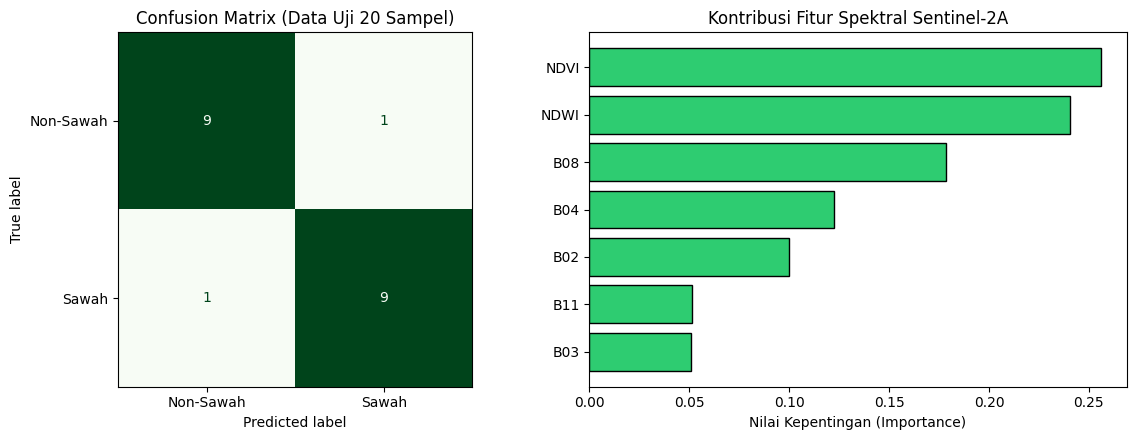

C:\Users\Fatihul Umam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


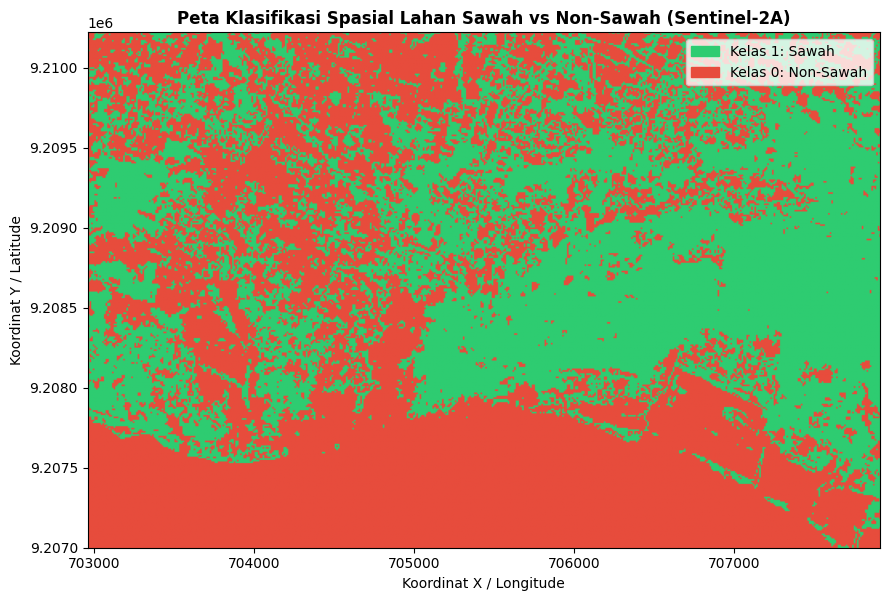

In [3]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# ==============================================================================
# A. VISUALISASI CONFUSION MATRIX & FEATURE IMPORTANCE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Greens", ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix (Data Uji 20 Sampel)")

# 2. Plot Tingkat Kepentingan Fitur (Band & Indeks Spektral)
importances = model_rf.feature_importances_
indices = np.argsort(importances)
axes[1].barh(
    range(len(indices)),
    importances[indices],
    color="#2ecc71",
    edgecolor="black",
)
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([fitur_kolom[i] for i in indices])
axes[1].set_xlabel("Nilai Kepentingan (Importance)")
axes[1].set_title("Kontribusi Fitur Spektral Sentinel-2A")

plt.tight_layout()
plt.savefig("evaluasi_klasifikasi_sawah.png", dpi=300)
plt.show()

# ==============================================================================
# B. KLASIFIKASI SELURUH PIKSEL CITRA (.TIF) MENJADI PETA SAWAH VS NON-SAWAH
# ==============================================================================
with rasterio.open("./source/klasifikasi_sawah/sentinel2_sawah_nonsawah.tif") as src:
  img = src.read()  # Shape: (5 bands, height, width)
  profil_raster = src.profile
  bounds = src.bounds

# Ambil masing-masing band (B02, B03, B04, B08, B11)
b02, b03, b04, b08, b11 = (
    img[0].astype(float),
    img[1].astype(float),
    img[2].astype(float),
    img[3].astype(float),
    img[4].astype(float),
)

# Hitung NDVI dan NDWI untuk seluruh piksel di citra .tif
ndvi_map = (b08 - b04) / (b08 + b04 + 1e-6)
ndwi_map = (b03 - b08) / (b03 + b08 + 1e-6)

# Susun seluruh piksel menjadi matriks 2D (baris = piksel, kolom = 7 fitur)
stack_fitur = np.stack([b02, b03, b04, b08, b11, ndvi_map, ndwi_map], axis=-1)
h, w, c = stack_fitur.shape
piksel_2d = np.nan_to_num(stack_fitur.reshape(-1, c), nan=0.0)

# Prediksi seluruh piksel menggunakan model Random Forest yang sudah dilatih
prediksi_label = model_rf.predict(piksel_2d)

# Ubah hasil prediksi ('Sawah' -> 1, 'Non-Sawah' -> 0) kembali ke ukuran gambar 2D (h, w)
peta_biner = np.where(prediksi_label == "Sawah", 1, 0).reshape(h, w)

# Tampilkan Peta Hasil Klasifikasi Spasial
plt.figure(figsize=(9, 7))
cmap_sawah = mcolors.ListedColormap(["#e74c3c", "#2ecc71"])  # Merah & Hijau
plt.imshow(
    peta_biner,
    cmap=cmap_sawah,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
)

# Legenda Peta
patch_sawah = mpatches.Patch(color="#2ecc71", label="Kelas 1: Sawah")
patch_nonsawah = mpatches.Patch(color="#e74c3c", label="Kelas 0: Non-Sawah")
plt.legend(handles=[patch_sawah, patch_nonsawah], loc="upper right")
plt.title(
    "Peta Klasifikasi Spasial Lahan Sawah vs Non-Sawah (Sentinel-2A)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Koordinat X / Longitude")
plt.ylabel("Koordinat Y / Latitude")
plt.tight_layout()
plt.savefig("peta_klasifikasi_raster_sawah.png", dpi=300)
plt.show()